# Stage 3: MPS-Native Taylor-Green Vortex

Taylor-Green vortex: decaying periodic flow with **exact analytical solution**.
No boundary conditions — just collision + cyclic streaming.

### Sections
1. Simulation (vanilla + MPS, store all data)
2. Error vs Analytical
3. Mass Conservation
4. Velocity Decay & Fields
5. Bond Dimension & Convergence
6. MPS-Native Observables

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from lbm import D2Q9, compute_equilibrium, stream, collide_bgk
from lbm.collision import compute_moments
from simulations.taylor_green import analytical_taylor_green
from tn.compression import compress_populations, decompress_populations
from tn_lbm.collision import collide_bgk_mps
from tn_lbm.streaming import stream_all_populations
from tn_lbm.observables import (
    mps_evaluate_at_point, mps_coarse_field,
    check_convergence_mps
)
from tn_lbm.arithmetic import mps_sum_value

print("All modules loaded successfully")

All modules loaded successfully


## 1. Simulation

Run vanilla and MPS-native side by side. Store everything: error vs analytical, mass, velocity decay, bond dimension, convergence metric.

In [2]:
# Parameters
n = 64; Re = 100; U0 = 0.1
nu = U0 * n / Re
tau = 3 * nu + 0.5
k = 2 * np.pi / n
tau_decay = 1 / (2 * nu * k**2)
mapping = 'snake'
max_bond_tg = 64

nt = int(2 * tau_decay)
snapshot_every = max(1, nt // 40)  # ~40 snapshots
initial_mass = float(n * n)

print(f"Taylor-Green Vortex ({n}x{n}, Re={Re}, U0={U0})")
print(f"  nu={nu:.6f}, tau={tau:.4f}")
print(f"  tau_decay={tau_decay:.0f} steps, running for {nt} steps ({nt/tau_decay:.1f} decay times)")
print(f"  max_bond={max_bond_tg}, mapping={mapping}")
print("=" * 60)

# Initialize from analytical solution at t=0
rho_init = np.ones((n, n))
u_init = analytical_taylor_green(n, t=0, nu=nu, U0=U0)
f_init = compute_equilibrium(D2Q9, rho_init, u_init)

# --- Storage ---
van = {'t': [], 'l2_err': [], 'max_speed': [], 'mass': [], 'du': []}
mps = {'t': [], 'l2_err': [], 'max_speed': [], 'mass': [], 'du': [], 'mean_chi': []}

# --- Vanilla run ---
print("\nRunning vanilla LBM...")
f_van = f_init.copy()
u_prev_van = u_init.copy()

for t in range(nt + 1):
    if t > 0:
        f_van = collide_bgk(D2Q9, f_van, tau)
        f_van = stream(D2Q9, f_van)  # periodic, no BC

    if t % snapshot_every == 0:
        rho_v, u_v = compute_moments(D2Q9, f_van)
        u_exact = analytical_taylor_green(n, t=t, nu=nu, U0=U0)

        u_diff = np.sqrt((u_v[0] - u_exact[0])**2 + (u_v[1] - u_exact[1])**2)
        u_ref_norm = np.linalg.norm(np.sqrt(u_exact[0]**2 + u_exact[1]**2))
        l2_err = np.linalg.norm(u_diff) / (u_ref_norm + 1e-30)

        du_v = np.sqrt(np.sum((u_v - u_prev_van)**2) / (np.sum(u_v**2) + 1e-30))
        u_prev_van = u_v.copy()

        van['t'].append(t)
        van['l2_err'].append(l2_err)
        van['max_speed'].append(np.max(np.sqrt(u_v[0]**2 + u_v[1]**2)))
        van['mass'].append(np.sum(rho_v))
        van['du'].append(du_v)

print(f"  Done. Final L2 error: {van['l2_err'][-1]:.2e}")

# --- MPS-native run ---
print(f"\nRunning MPS-native (max_bond={max_bond_tg})...")
mps_list, meta = compress_populations(f_init, mapping=mapping)
moments_old = None
t0 = time.time()

for t in range(nt + 1):
    if t > 0:
        mps_list, moments_new = collide_bgk_mps(mps_list, D2Q9, tau, n,
                                                  max_bond=max_bond_tg, return_moments=True)
        mps_list = stream_all_populations(mps_list, meta, D2Q9,
                                           max_bond=max_bond_tg, cyclic=True)
    else:
        moments_new = None

    if t % snapshot_every == 0:
        f_mps = decompress_populations(mps_list, meta)
        rho_m, u_m = compute_moments(D2Q9, f_mps)
        u_exact = analytical_taylor_green(n, t=t, nu=nu, U0=U0)

        u_diff = np.sqrt((u_m[0] - u_exact[0])**2 + (u_m[1] - u_exact[1])**2)
        u_ref_norm = np.linalg.norm(np.sqrt(u_exact[0]**2 + u_exact[1]**2))
        l2_err = np.linalg.norm(u_diff) / (u_ref_norm + 1e-30)

        # Convergence from moments (if available)
        if moments_old is not None and moments_new is not None:
            _, du_m = check_convergence_mps(
                mps_list, None, mode='velocity',
                moments_new=moments_new, moments_old=moments_old)
        else:
            du_m = float('nan')

        mean_chi = np.mean([m.max_bond() for m in mps_list])

        mps['t'].append(t)
        mps['l2_err'].append(l2_err)
        mps['max_speed'].append(np.max(np.sqrt(u_m[0]**2 + u_m[1]**2)))
        mps['mass'].append(np.sum(rho_m))
        mps['du'].append(du_m)
        mps['mean_chi'].append(mean_chi)

    if moments_new is not None:
        moments_old = moments_new

    if t % (nt // 5) == 0 and t > 0:
        print(f"  t={t}, elapsed={time.time()-t0:.0f}s")

elapsed = time.time() - t0
print(f"  Done in {elapsed:.0f}s. Final L2 error: {mps['l2_err'][-1]:.2e}")

Taylor-Green Vortex (64x64, Re=100, U0=0.1)
  nu=0.064000, tau=0.6920
  tau_decay=811 steps, running for 1621 steps (2.0 decay times)
  max_bond=64, mapping=snake

Running vanilla LBM...
  Done. Final L2 error: 7.26e-03

Running MPS-native (max_bond=64)...
  t=324, elapsed=139s
  t=648, elapsed=274s
  t=972, elapsed=407s
  t=1296, elapsed=538s
  t=1620, elapsed=670s
  Done in 670s. Final L2 error: 6.87e-03


## 2. Error vs Analytical Solution

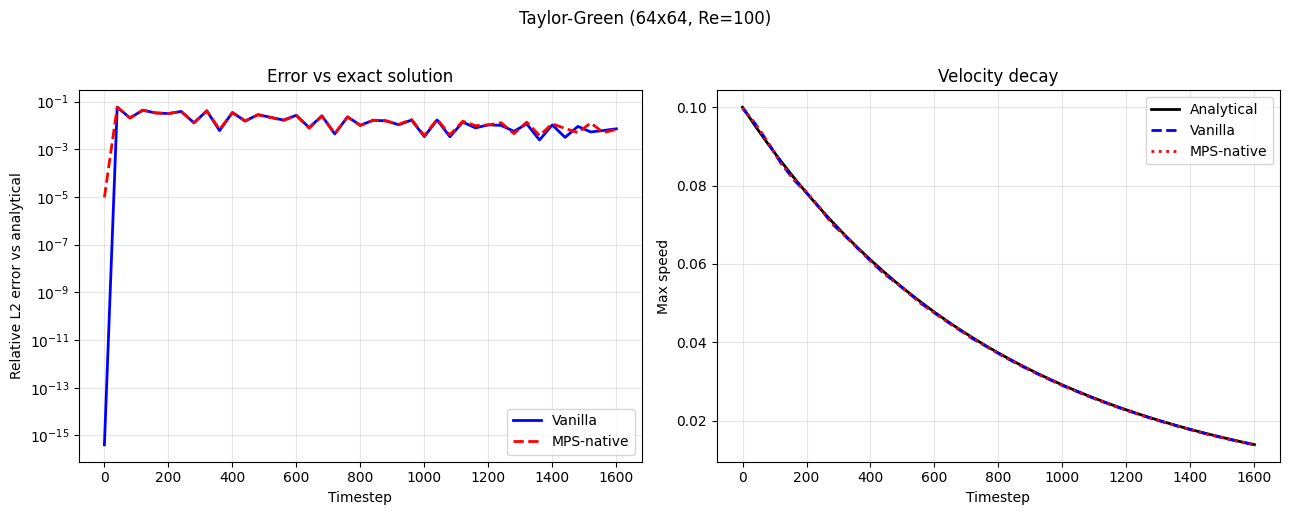

Final L2 error vs analytical:
  Vanilla:    7.26e-03
  MPS-native: 6.87e-03


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.semilogy(van['t'], van['l2_err'], 'b-', linewidth=2, label='Vanilla')
ax.semilogy(mps['t'], mps['l2_err'], 'r--', linewidth=2, label='MPS-native')
ax.set_xlabel('Timestep'); ax.set_ylabel('Relative L2 error vs analytical')
ax.set_title('Error vs exact solution'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
t_theory = np.array(van['t'])
speed_theory = U0 * np.exp(-2 * nu * k**2 * t_theory)
ax.plot(t_theory, speed_theory, 'k-', linewidth=2, label='Analytical')
ax.plot(van['t'], van['max_speed'], 'b--', linewidth=2, label='Vanilla')
ax.plot(mps['t'], mps['max_speed'], 'r:', linewidth=2, label='MPS-native')
ax.set_xlabel('Timestep'); ax.set_ylabel('Max speed')
ax.set_title('Velocity decay'); ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle(f'Taylor-Green ({n}x{n}, Re={Re})', y=1.02)
plt.tight_layout()
plt.show()

print(f"Final L2 error vs analytical:")
print(f"  Vanilla:    {van['l2_err'][-1]:.2e}")
print(f"  MPS-native: {mps['l2_err'][-1]:.2e}")

## 3. Mass Conservation

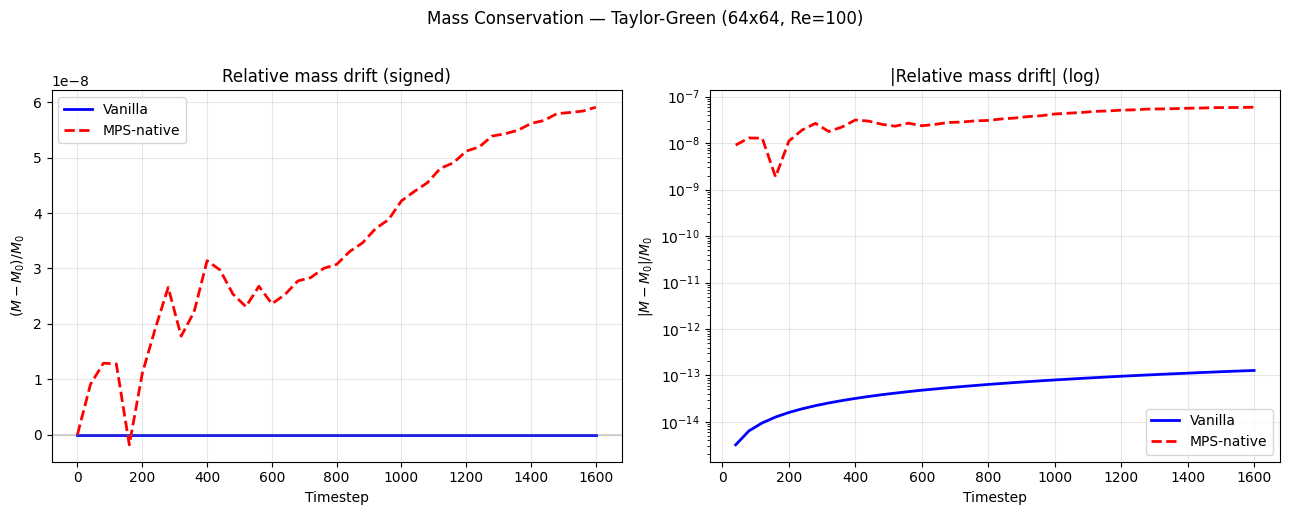

Final mass drift:
  Vanilla:    -1.28e-13
  MPS-native: 5.91e-08


In [4]:
van_mass_rel = [(m - initial_mass) / initial_mass for m in van['mass']]
mps_mass_rel = [(m - initial_mass) / initial_mass for m in mps['mass']]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(van['t'], van_mass_rel, 'b-', linewidth=2, label='Vanilla')
ax.plot(mps['t'], mps_mass_rel, 'r--', linewidth=2, label='MPS-native')
ax.axhline(0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Timestep'); ax.set_ylabel('$(M - M_0) / M_0$')
ax.set_title('Relative mass drift (signed)'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
rd_v = [max(abs(r), 1e-16) for r in van_mass_rel[1:]]
rd_m = [max(abs(r), 1e-16) for r in mps_mass_rel[1:]]
ax.semilogy(van['t'][1:], rd_v, 'b-', linewidth=2, label='Vanilla')
ax.semilogy(mps['t'][1:], rd_m, 'r--', linewidth=2, label='MPS-native')
ax.set_xlabel('Timestep'); ax.set_ylabel('$|M - M_0| / M_0$')
ax.set_title('|Relative mass drift| (log)'); ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle(f'Mass Conservation — Taylor-Green ({n}x{n}, Re={Re})', y=1.02)
plt.tight_layout()
plt.show()

print(f"Final mass drift:")
print(f"  Vanilla:    {van_mass_rel[-1]:.2e}")
print(f"  MPS-native: {mps_mass_rel[-1]:.2e}")

## 4. Velocity Fields

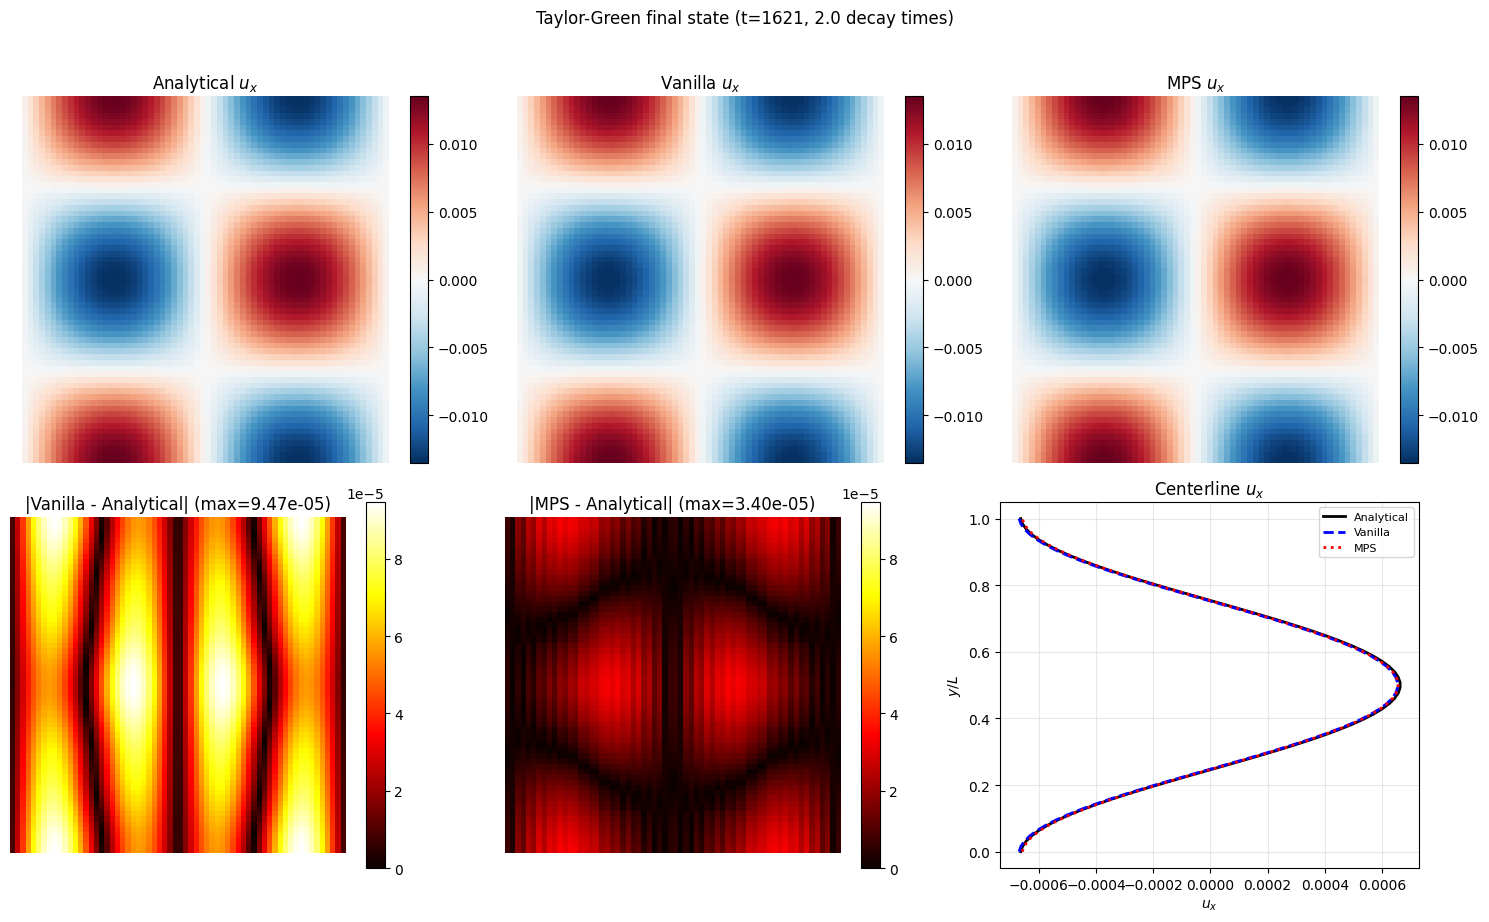

In [5]:
_, u_van_final = compute_moments(D2Q9, f_van)
f_mps_final = decompress_populations(mps_list, meta)
_, u_mps_final = compute_moments(D2Q9, f_mps_final)
u_exact_final = analytical_taylor_green(n, t=nt, nu=nu, U0=U0)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

vmax = max(np.abs(u_exact_final[0]).max(), np.abs(u_van_final[0]).max())
for ax, (field, title) in zip(axes[0], [
    (u_exact_final[0], 'Analytical $u_x$'),
    (u_van_final[0], 'Vanilla $u_x$'),
    (u_mps_final[0], 'MPS $u_x$')
]):
    im = ax.imshow(field.T, origin='lower', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.set_title(title); ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046)

err_van = np.abs(u_van_final[0] - u_exact_final[0])
err_mps = np.abs(u_mps_final[0] - u_exact_final[0])
err_max = max(err_van.max(), err_mps.max())

im3 = axes[1,0].imshow(err_van.T, origin='lower', cmap='hot', vmin=0, vmax=err_max)
axes[1,0].set_title(f'|Vanilla - Analytical| (max={err_van.max():.2e})')
plt.colorbar(im3, ax=axes[1,0]); axes[1,0].axis('off')

im4 = axes[1,1].imshow(err_mps.T, origin='lower', cmap='hot', vmin=0, vmax=err_max)
axes[1,1].set_title(f'|MPS - Analytical| (max={err_mps.max():.2e})')
plt.colorbar(im4, ax=axes[1,1]); axes[1,1].axis('off')

mid = n // 2
y_coords = np.linspace(0, 1, n)
axes[1,2].plot(u_exact_final[0, mid, :], y_coords, 'k-', linewidth=2, label='Analytical')
axes[1,2].plot(u_van_final[0, mid, :], y_coords, 'b--', linewidth=2, label='Vanilla')
axes[1,2].plot(u_mps_final[0, mid, :], y_coords, 'r:', linewidth=2, label='MPS')
axes[1,2].set_xlabel('$u_x$'); axes[1,2].set_ylabel('$y / L$')
axes[1,2].set_title('Centerline $u_x$'); axes[1,2].legend(fontsize=8)
axes[1,2].grid(True, alpha=0.3)

plt.suptitle(f'Taylor-Green final state (t={nt}, {nt/tau_decay:.1f} decay times)', y=1.02)
plt.tight_layout()
plt.show()

## 5. Bond Dimension & Convergence

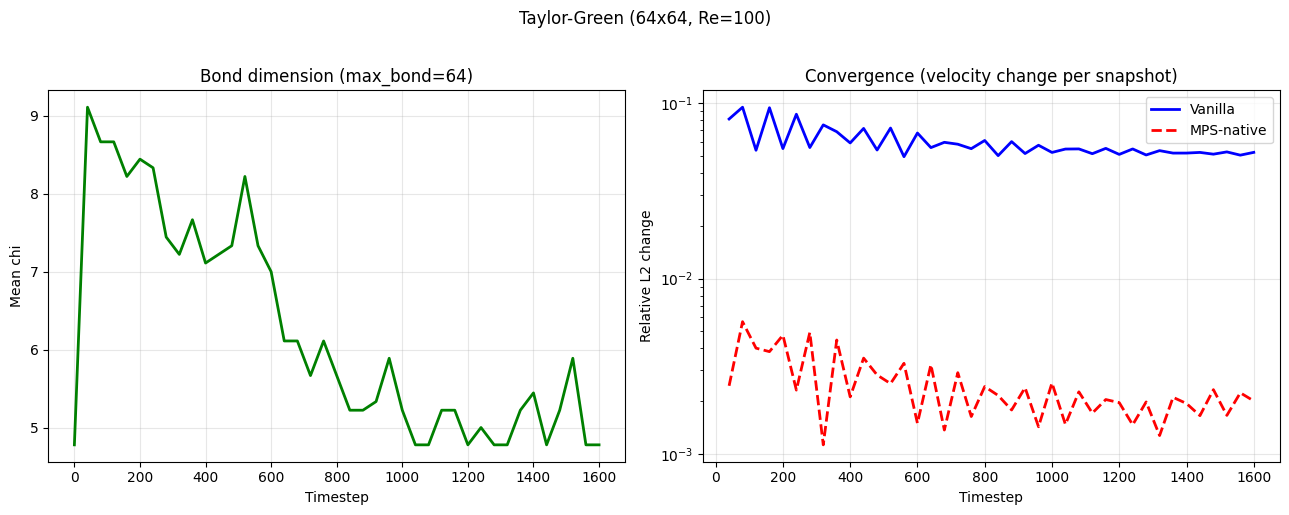

Bond dimension: min=4.8, max=9.1


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bond dimension over time
ax = axes[0]
ax.plot(mps['t'], mps['mean_chi'], 'g-', linewidth=2)
ax.set_xlabel('Timestep'); ax.set_ylabel('Mean chi')
ax.set_title(f'Bond dimension (max_bond={max_bond_tg})'); ax.grid(True, alpha=0.3)

# Convergence (du) over time
ax = axes[1]
ax.semilogy(van['t'][1:], van['du'][1:], 'b-', linewidth=2, label='Vanilla')
mps_du_valid = [(t, d) for t, d in zip(mps['t'], mps['du']) if not np.isnan(d)]
if mps_du_valid:
    ax.semilogy([x[0] for x in mps_du_valid], [x[1] for x in mps_du_valid],
                'r--', linewidth=2, label='MPS-native')
ax.set_xlabel('Timestep'); ax.set_ylabel('Relative L2 change')
ax.set_title('Convergence (velocity change per snapshot)'); ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle(f'Taylor-Green ({n}x{n}, Re={Re})', y=1.02)
plt.tight_layout()
plt.show()

print(f"Bond dimension: min={min(mps['mean_chi']):.1f}, max={max(mps['mean_chi']):.1f}")

## 6. MPS-Native Observables

Extract data from the final MPS state without decompression.

In [8]:
# Point evaluation: centerline ux — MPS vs decompressed vs vanilla vs analytical
print("Centerline ux point evaluation:")
print(f"{'y/L':>6} | {'Analytical':>12} | {'Vanilla':>12} | {'MPS decomp':>12} | {'MPS point':>12} | {'pt vs dec':>10} | {'pt vs ana':>10} | {'pt vs van':>10}")
print("-" * 105)

mid = n // 2
max_pt_err_dec = 0
max_pt_err_ana = 0
max_pt_err_van = 0

for y_idx in range(0, n, n // 8):
    # MPS point evaluation
    rho_pt = sum(mps_evaluate_at_point(mps_list[i], mid, y_idx, n, meta) for i in range(9))
    rhou_x_pt = sum(D2Q9.c[i,0] * mps_evaluate_at_point(mps_list[i], mid, y_idx, n, meta)
                    for i in range(9))
    ux_pt = rhou_x_pt / rho_pt

    ux_decomp = u_mps_final[0, mid, y_idx]
    ux_van = u_van_final[0, mid, y_idx]
    ux_ana = u_exact_final[0, mid, y_idx]

    err_dec = abs(ux_pt - ux_decomp)
    err_ana = abs(ux_pt - ux_ana)
    err_van = abs(ux_pt - ux_van)
    max_pt_err_dec = max(max_pt_err_dec, err_dec)
    max_pt_err_ana = max(max_pt_err_ana, err_ana)
    max_pt_err_van = max(max_pt_err_van, err_van)

    print(f"{y_idx/n:>6.3f} | {ux_ana:>12.6e} | {ux_van:>12.6e} | {ux_decomp:>12.6e} | {ux_pt:>12.6e} | {err_dec:>10.2e} | {err_ana:>10.2e} | {err_van:>10.2e}")

print(f"\nMax errors:")
print(f"  MPS point vs MPS decompressed: {max_pt_err_dec:.2e}  (compression roundtrip)")
print(f"  MPS point vs analytical:       {max_pt_err_ana:.2e}  (LBM discretization + compression)")
print(f"  MPS point vs vanilla:          {max_pt_err_van:.2e}  (compression only)")

# Mass from MPS
mass_mps_final = sum(mps_sum_value(mps_list[i]) for i in range(9))
print(f"\nMass from MPS: {mass_mps_final:.6f} (initial: {initial_mass:.0f}, drift: {(mass_mps_final-initial_mass)/initial_mass:.2e})")

Centerline ux point evaluation:
   y/L |   Analytical |      Vanilla |   MPS decomp |    MPS point |  pt vs dec |  pt vs ana |  pt vs van
---------------------------------------------------------------------------------------------------------
 0.000 | -6.633726e-04 | -6.692796e-04 | -6.581324e-04 | -6.581324e-04 |   3.82e-17 |   5.24e-06 |   1.11e-05
 0.125 | -4.460311e-04 | -4.525779e-04 | -4.433169e-04 | -4.433169e-04 |   1.08e-19 |   2.71e-06 |   9.26e-06
 0.250 | 3.258940e-05 | 2.519575e-05 | 3.066719e-05 | 3.066719e-05 |   3.82e-17 |   1.92e-06 |   5.47e-06
 0.375 | 4.921194e-04 | 4.838989e-04 | 4.863195e-04 | 4.863195e-04 |   1.75e-17 |   5.80e-06 |   2.42e-06
 0.500 | 6.633726e-04 | 6.545750e-04 | 6.560678e-04 | 6.560678e-04 |   4.14e-17 |   7.30e-06 |   1.49e-06
 0.625 | 4.460311e-04 | 4.379287e-04 | 4.405293e-04 | 4.405293e-04 |   2.17e-19 |   5.50e-06 |   2.60e-06
 0.750 | -3.258940e-05 | -3.989154e-05 | -3.389484e-05 | -3.389484e-05 |   1.73e-17 |   1.31e-06 |   6.00e-06
 0

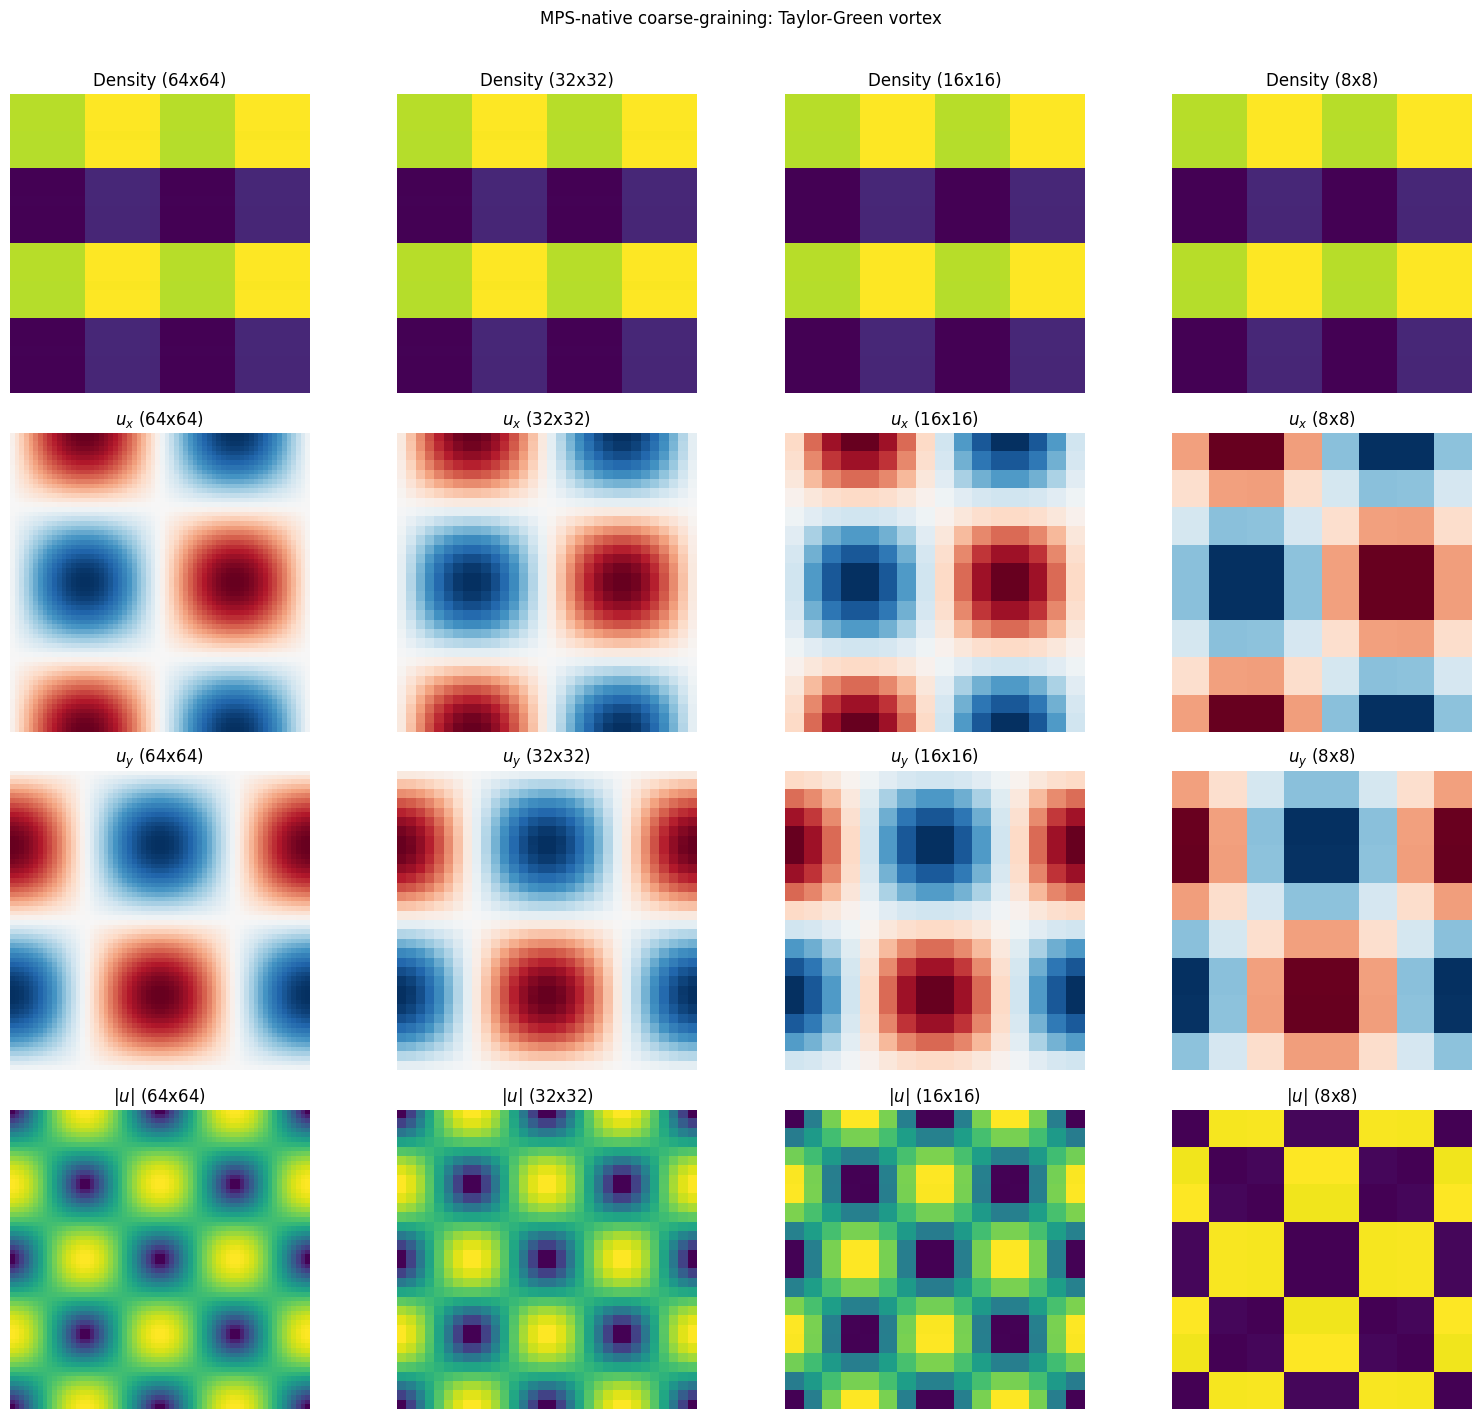

Coarse field validation (max error vs dense reshape+sum):
  rho level=1 (32x32): err=2.66e-15
  rho level=2 (16x16): err=7.11e-15
  rho level=3 (8x8): err=2.84e-14
  ux level=1 (32x32): err=2.08e-17
  ux level=2 (16x16): err=1.11e-16
  ux level=3 (8x8): err=3.33e-16
  uy level=1 (32x32): err=3.47e-17
  uy level=2 (16x16): err=1.67e-16
  uy level=3 (8x8): err=4.44e-16


In [9]:
# Coarse-graining: density, ux, uy, speed
from tn_lbm.collision import compute_moments_mps, compute_inverse_density_mps, build_ones_mps
from tn_lbm.arithmetic import mps_hadamard
from tn.compression import qtt_to_field

rho_mps_tg, rhou_x_mps_tg, rhou_y_mps_tg = compute_moments_mps(mps_list, D2Q9, max_bond=max_bond_tg)
ones_tg = build_ones_mps(len(mps_list[0].tensors))
inv_rho_tg = compute_inverse_density_mps(rho_mps_tg, ones_tg, n, max_bond=max_bond_tg)
ux_mps_tg = mps_hadamard(rhou_x_mps_tg, inv_rho_tg, max_bond=max_bond_tg)
uy_mps_tg = mps_hadamard(rhou_y_mps_tg, inv_rho_tg, max_bond=max_bond_tg)

fig, axes = plt.subplots(4, 4, figsize=(16, 14))

fields = [
    (rho_mps_tg, 'Density', 'viridis'),
    (ux_mps_tg, '$u_x$', 'RdBu_r'),
    (uy_mps_tg, '$u_y$', 'RdBu_r'),
]

for row, (field_mps, field_name, cmap) in enumerate(fields):
    full = qtt_to_field(field_mps, meta)
    axes[row, 0].imshow(full.T, origin='lower', cmap=cmap)
    axes[row, 0].set_title(f'{field_name} ({n}x{n})'); axes[row, 0].axis('off')
    for col, level in enumerate([1, 2, 3]):
        coarse = mps_coarse_field(field_mps, meta, coarse_level=level)
        n_c = n // (2**level)
        axes[row, col+1].imshow(coarse.T, origin='lower', cmap=cmap)
        axes[row, col+1].set_title(f'{field_name} ({n_c}x{n_c})'); axes[row, col+1].axis('off')

# Row 4: speed
ux_full = qtt_to_field(ux_mps_tg, meta)
uy_full = qtt_to_field(uy_mps_tg, meta)
speed_full = np.sqrt(ux_full**2 + uy_full**2)
axes[3, 0].imshow(speed_full.T, origin='lower', cmap='viridis')
axes[3, 0].set_title(f'$|u|$ ({n}x{n})'); axes[3, 0].axis('off')

for col, level in enumerate([1, 2, 3]):
    ux_c = mps_coarse_field(ux_mps_tg, meta, coarse_level=level)
    uy_c = mps_coarse_field(uy_mps_tg, meta, coarse_level=level)
    n_c = n // (2**level)
    block = 2**level
    speed_c = np.sqrt((ux_c / block**2)**2 + (uy_c / block**2)**2)
    axes[3, col+1].imshow(speed_c.T, origin='lower', cmap='viridis')
    axes[3, col+1].set_title(f'$|u|$ ({n_c}x{n_c})'); axes[3, col+1].axis('off')

plt.suptitle('MPS-native coarse-graining: Taylor-Green vortex', y=1.01)
plt.tight_layout()
plt.show()

# Validation
print("Coarse field validation (max error vs dense reshape+sum):")
for field_mps, name in [(rho_mps_tg, 'rho'), (ux_mps_tg, 'ux'), (uy_mps_tg, 'uy')]:
    full = qtt_to_field(field_mps, meta)
    for level in [1, 2, 3]:
        coarse = mps_coarse_field(field_mps, meta, coarse_level=level)
        n_c = n // (2**level)
        block = 2**level
        dense_coarse = full.reshape(n_c, block, n_c, block).sum(axis=(1, 3))
        err = np.max(np.abs(coarse - dense_coarse))
        print(f"  {name} level={level} ({n_c}x{n_c}): err={err:.2e}")